# SPEC 05 — LIN28A Binding-Site Burden and Robustness Analysis

**Objective**: Characterize the LIN28A binding-site landscape (Table S3A) for each transcript in Table S5. Assess whether high-confidence direct-repression candidates carry more / more robust binding sites than background transcripts.

> **Note**: No 5′UTR/CDS/3′UTR region annotation is performed — Table S3A does not include region labels. See `notes/05_binding_position_unavailable_note.md`.

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import sys

BASE  = '/home/sezero/data/BI_2026-1/Guided_Mission_1/colab-biolab/lin28a_project'
OUT_T = f'{BASE}/results/tables'
OUT_F = f'{BASE}/results/figures'
OUT_N = f'{BASE}/notes'

ribo_col = 'Ribosome density change (log2)'
rna_col  = 'RNA-seq mRNA change upon Lin28a KD (log2)'
fdr_col  = 'CLIP-seq FDR'
clip_col = 'mean_CLIP_enrichment'

print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}  numpy: {np.__version__}  matplotlib: {matplotlib.__version__}')
print(f'scipy: {__import__("scipy").__version__}')

Python: 3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]
pandas: 2.3.3  numpy: 2.2.6  matplotlib: 3.10.8
scipy: 1.15.3


## 1. Binding-site features (from Table S3A)

The analysis script (`/tmp/spec05_analysis.py`) loaded Table S3A (65,534 rows, 6,606 unique transcripts) and aggregated per-transcript features:

- `binding_site_count` — total number of detected crosslinking sites
- `has_binding_site` — True / False flag
- `n_sites_detected_2plus_libraries` — sites detected in ≥2 of 3 CLIP libraries
- `n_sites_detected_3_libraries` — sites detected in all 3 libraries
- `max/mean_detected_libraries` — robustness per transcript
- `depth_max/mean_35L33G`, `depth_max/mean_2J3`, `depth_max/mean_polyclonal`
- `entropy_max/mean_35L33G`, `entropy_max/mean_2J3`, `entropy_max/mean_polyclonal`

NaN values excluded in all per-transcript aggregations.

In [2]:
agg = pd.read_csv(f'{OUT_T}/05_binding_site_features_by_transcript.csv')
print(f'Aggregated binding-site table: {agg.shape[0]} transcripts x {agg.shape[1]} columns')
print(f'binding_site_count: min={agg["binding_site_count"].min()}  '
      f'median={agg["binding_site_count"].median():.0f}  '
      f'max={agg["binding_site_count"].max()}')
agg.head(5)

Aggregated binding-site table: 6606 transcripts x 19 columns
binding_site_count: min=1  median=6  max=267


,Accession,binding_site_count,n_sites_detected_2plus_libraries,n_sites_detected_3_libraries,max_detected_libraries,mean_detected_libraries,depth_max_35L33G,depth_mean_35L33G,depth_max_2J3,depth_mean_2J3,depth_max_polyclonal,depth_mean_polyclonal,entropy_max_35L33G,entropy_mean_35L33G,entropy_max_2J3,entropy_mean_2J3,entropy_max_polyclonal,entropy_mean_polyclonal,has_binding_site
0,NM_001001181,7,5,2,3,2.000000,214.0,119.666667,245.0,116.25,182.0,59.285714,1.292680,1.157814,1.217480,0.980320,1.232640,0.899991,True
1,NM_001001182,7,4,1,3,1.714286,26.0,23.500000,33.0,22.20,35.0,27.000000,1.038240,1.018590,1.063349,0.790865,1.172456,0.864393,True
2,NM_001001295,1,0,0,1,1.000000,26.0,26.000000,NaN,NaN,NaN,NaN,1.001768,1.001768,NaN,NaN,NaN,NaN,True
3,NM_001001446,1,0,0,1,1.000000,18.0,18.000000,NaN,NaN,NaN,NaN,1.089310,1.089310,NaN,NaN,NaN,NaN,True
4,NM_001001493,1,0,0,1,1.000000,NaN,NaN,39.0,39.00,NaN,NaN,NaN,NaN,1.037748,1.037748,NaN,NaN,True


## 2. Merge with Table S5 and assign candidate group labels

Transcripts absent from Table S3A are assigned `binding_site_count = 0`, `has_binding_site = False`.

In [3]:
df = pd.read_csv(f'{OUT_T}/05_s5_with_binding_site_features.csv')
print(f'Rows: {df.shape[0]}  Cols: {df.shape[1]}')
print()
grp_order = ['Not_candidate', 'A_only', 'B_only', 'A_and_B_overlap']
for grp in grp_order:
    sub = df[df['candidate_group'] == grp]
    has = sub['has_binding_site'].sum()
    print(f'  {grp}: n={len(sub)}, has_binding_site={int(has)} ({has/len(sub)*100:.1f}%)')

Rows: 16465  Cols: 26

  Not_candidate: n=16409, has_binding_site=6561 (40.0%)
  A_only: n=8, has_binding_site=7 (87.5%)
  B_only: n=0, has_binding_site=0 (nan%)
  A_and_B_overlap: n=48, has_binding_site=35 (72.9%)


/tmp/ipykernel_1928663/3350494415.py:8: RuntimeWarning: invalid value encountered in scalar divide
  print(f'  {grp}: n={len(sub)}, has_binding_site={int(has)} ({has/len(sub)*100:.1f}%)')


## 3. Binding-site count by candidate group (Figure 05-1)

Boxplot with individual points overlaid for small-n groups. y-axis truncated at 99th percentile for readability.

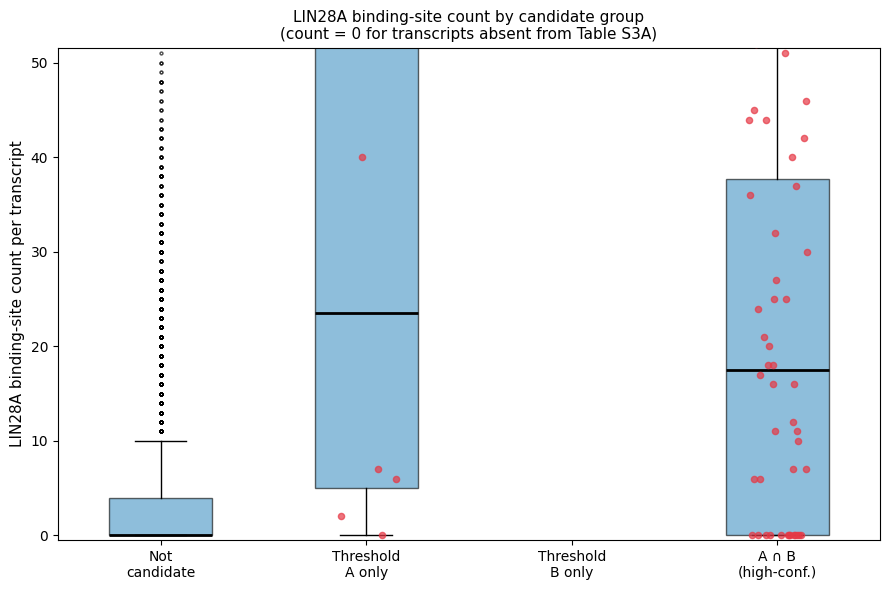

In [4]:
grp_labels = {
    'Not_candidate':    'Not\ncandidate',
    'A_only':           'Threshold\nA only',
    'B_only':           'Threshold\nB only',
    'A_and_B_overlap':  'A ∩ B\n(high-conf.)',
}

fig, ax = plt.subplots(figsize=(9, 6))
data_by_grp = [df[df['candidate_group'] == g]['binding_site_count'].values
               for g in grp_order]
ax.boxplot(data_by_grp,
           positions=range(len(grp_order)),
           widths=0.5, patch_artist=True,
           boxprops=dict(facecolor='#4393C3', alpha=0.6),
           medianprops=dict(color='black', linewidth=2),
           whiskerprops=dict(linewidth=1),
           capprops=dict(linewidth=1),
           flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))

for i, grp in enumerate(grp_order):
    vals = df[df['candidate_group'] == grp]['binding_site_count'].values
    if len(vals) <= 200:
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   c='#E63946', alpha=0.7, s=20, zorder=4)

ax.set_xticks(range(len(grp_order)))
ax.set_xticklabels([grp_labels[g] for g in grp_order], fontsize=10)
ax.set_ylabel('LIN28A binding-site count per transcript', fontsize=11)
ax.set_title('LIN28A binding-site count by candidate group\n'
             '(count = 0 for transcripts absent from Table S3A)', fontsize=11)
ax.set_ylim(-0.5, max(df['binding_site_count'].quantile(0.99) * 1.2, 10))
fig.tight_layout()
fig.savefig(f'{OUT_F}/05_binding_site_count_by_candidate_group.png', dpi=300)
plt.show()

In [5]:
pd.read_csv(f'{OUT_T}/05_binding_site_count_by_candidate_group_summary.csv')

,candidate_group,n_transcripts,mean_binding_site_count,median_binding_site_count,min_binding_site_count,max_binding_site_count
0,Not_candidate,16409,3.903346,0.0,0.0,267.0
1,A_only,8,55.375000,23.5,0.0,177.0
2,B_only,0,NaN,NaN,NaN,NaN
3,A_and_B_overlap,48,21.625000,17.5,0.0,68.0


## 4. Spearman correlation: binding-site count vs ribosome density change (Figure 05-2)

Computed across all S5 transcripts with non-NA ribosome density change and FDR data.

In [6]:
df_cor = df.dropna(subset=['binding_site_count', ribo_col, rna_col, fdr_col]).copy()
rho,     pval     = stats.spearmanr(df_cor['binding_site_count'], df_cor[ribo_col])
df_cor_has        = df_cor[df_cor['binding_site_count'] > 0]
rho_has, pval_has = stats.spearmanr(df_cor_has['binding_site_count'], df_cor_has[ribo_col])

print(f'n (all, non-NA):         {len(df_cor)}')
print(f'Spearman rho (all):      {rho:.4f}   p = {pval:.3e}')
print(f'n (has_binding_site):    {len(df_cor_has)}')
print(f'Spearman rho (has site): {rho_has:.4f}   p = {pval_has:.3e}')

n (all, non-NA):         5649
Spearman rho (all):      0.0037   p = 7.813e-01
n (has_binding_site):    3976
Spearman rho (has site): 0.0137   p = 3.889e-01


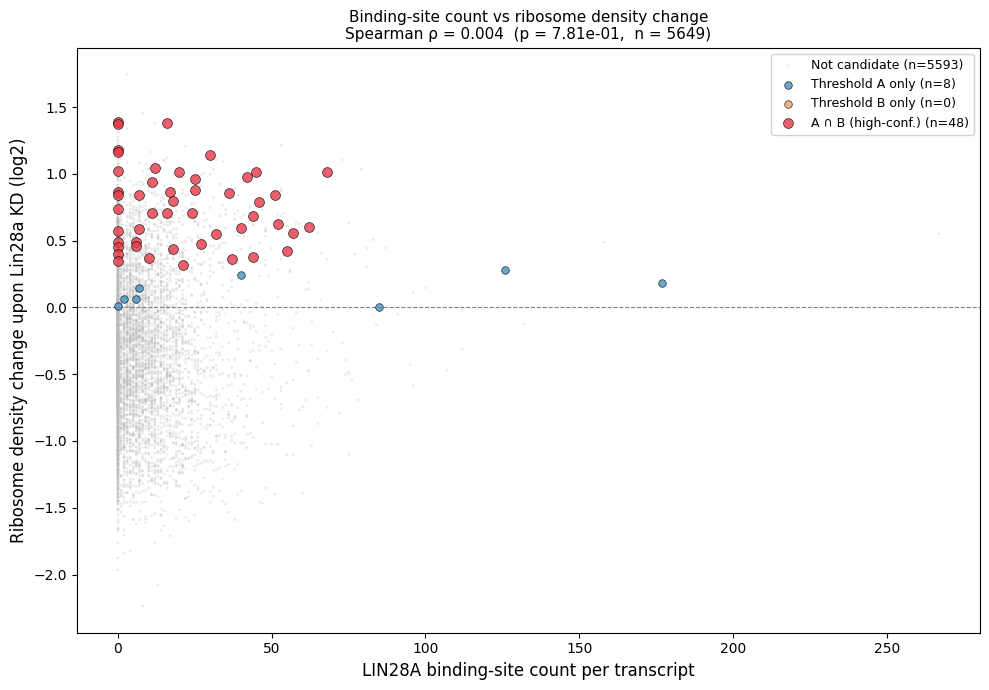

In [7]:
grp_colors = {
    'Not_candidate': '#BBBBBB', 'A_only': '#4393C3',
    'B_only': '#F4A261', 'A_and_B_overlap': '#E63946'
}
grp_sizes  = {'Not_candidate': 4, 'A_only': 30, 'B_only': 30, 'A_and_B_overlap': 50}
grp_zorder = {'Not_candidate': 1, 'A_only': 3, 'B_only': 3, 'A_and_B_overlap': 5}
grp_1line  = {
    'Not_candidate': 'Not candidate',
    'A_only': 'Threshold A only',
    'B_only': 'Threshold B only',
    'A_and_B_overlap': 'A ∩ B (high-conf.)',
}

fig, ax = plt.subplots(figsize=(10, 7))
for grp in grp_order:
    sub = df_cor[df_cor['candidate_group'] == grp]
    ax.scatter(sub['binding_site_count'], sub[ribo_col],
               c=grp_colors[grp],
               alpha=0.3 if grp == 'Not_candidate' else 0.8,
               s=grp_sizes[grp], zorder=grp_zorder[grp],
               edgecolors='none' if grp == 'Not_candidate' else 'black',
               linewidths=0 if grp == 'Not_candidate' else 0.5,
               label=f'{grp_1line[grp]} (n={len(sub)})',
               rasterized=(grp == 'Not_candidate'))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('LIN28A binding-site count per transcript', fontsize=12)
ax.set_ylabel('Ribosome density change upon Lin28a KD (log2)', fontsize=12)
ax.set_title(
    f'Binding-site count vs ribosome density change\n'
    f'Spearman ρ = {rho:.3f}  (p = {pval:.2e},  n = {len(df_cor)})',
    fontsize=11)
ax.legend(loc='upper right', fontsize=9, framealpha=0.85)
fig.tight_layout()
fig.savefig(f'{OUT_F}/05_binding_site_count_vs_ribosome_change.png', dpi=300)
plt.show()

## 5. Ribosome density change by binding-site burden category (Figure 05-3)

| Category | Description |
|---|---|
| 0 sites | Absent from Table S3A |
| 1 site | Single detected crosslinking event |
| 2–3 sites | Low-to-moderate binding |
| ≥4 sites | High binding-site burden |

> **Caveat**: 0-site transcripts may be excluded from Table S3A due to low read coverage rather than true absence of LIN28A binding.

In [8]:
def burden_cat(n):
    if n == 0:   return '0_sites'
    elif n == 1: return '1_site'
    elif n <= 3: return '2_to_3_sites'
    else:        return '4_or_more_sites'

burden_order  = ['0_sites', '1_site', '2_to_3_sites', '4_or_more_sites']
burden_labels = {'0_sites': '0 sites', '1_site': '1 site',
                 '2_to_3_sites': '2–3 sites', '4_or_more_sites': '≥4 sites'}
burden_colors = {'0_sites': '#CCCCCC', '1_site': '#99C4E8',
                 '2_to_3_sites': '#4393C3', '4_or_more_sites': '#1A5C8A'}

df['burden_category'] = df['binding_site_count'].apply(burden_cat)
pd.read_csv(f'{OUT_T}/05_ribosome_change_by_binding_site_burden_summary.csv')

,burden_category,n_transcripts_total,n_with_ribo_data,mean_ribo_change,median_ribo_change,min_ribo_change,max_ribo_change
0,0_sites,9862,1697,-0.276502,-0.294616,-1.964603,1.386181
1,1_site,1039,209,-0.328475,-0.372252,-1.532248,1.135705
2,2_to_3_sites,1288,519,-0.341170,-0.353301,-1.839999,1.744915
3,4_or_more_sites,4276,3276,-0.275430,-0.282009,-2.236666,1.453279


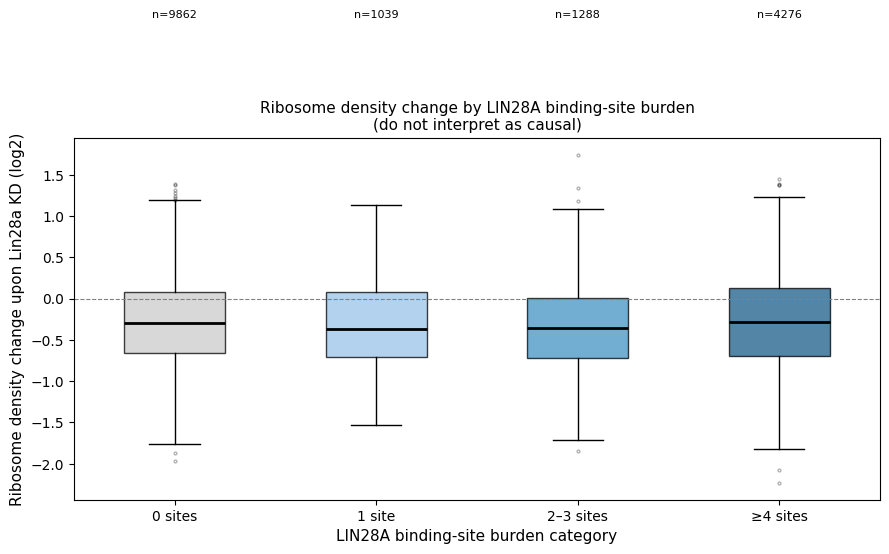

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
for pos, cat in enumerate(burden_order):
    vals = df[df['burden_category'] == cat][ribo_col].dropna().values
    if len(vals) == 0:
        continue
    ax.boxplot(vals, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=burden_colors[cat], alpha=0.75),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    n_total = int((df['burden_category'] == cat).sum())
    ax.text(pos, 3.5, f'n={n_total}', ha='center', va='top', fontsize=8)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(burden_order)))
ax.set_xticklabels([burden_labels[c] for c in burden_order], fontsize=10)
ax.set_xlabel('LIN28A binding-site burden category', fontsize=11)
ax.set_ylabel('Ribosome density change upon Lin28a KD (log2)', fontsize=11)
ax.set_title('Ribosome density change by LIN28A binding-site burden\n'
             '(do not interpret as causal)', fontsize=11)
fig.tight_layout()
fig.savefig(f'{OUT_F}/05_ribosome_change_by_binding_site_burden.png', dpi=300)
plt.show()

## 6. Candidate genes for BAM validation

Selection criteria:
- **Positive (3 genes)**: A∩B high-confidence candidates, sorted by CLIP enrichment × ribosome density increase
- **Negative control (1 gene)**: Not_candidate group, 0 binding sites, has ribosome data

In [10]:
df_val = pd.read_csv(f'{OUT_T}/05_candidate_genes_for_BAM_validation.csv')
pd.set_option('display.max_colwidth', 90)
df_val[['Gene Symbol', 'Accession', clip_col, ribo_col,
        'binding_site_count', 'functional_subclasses', 'reason_for_selection']]

,Gene Symbol,Accession,mean_CLIP_enrichment,Ribosome density change (log2),binding_site_count,functional_subclasses,reason_for_selection
0,Pgrmc1,NM_016783,4.031423,0.314690,21,membrane_or_transmembrane,"Top high-confidence candidate (A∩B): high CLIP enrichment, increased ribosome density ..."
1,Ktn1,NM_008477,2.913330,0.605197,62,other_or_unclear,"Top high-confidence candidate (A∩B): high CLIP enrichment, increased ribosome density ..."
2,Pvrl3,NM_021495,2.882220,0.867100,17,other/unclear,"Top high-confidence candidate (A∩B): high CLIP enrichment, increased ribosome density ..."
3,Unc45a,NM_133952,-1.860770,-1.964603,0,NaN,"Negative/comparison gene: Not_candidate group, no detected binding sites (binding_site..."


## 7. Key findings

| Metric | Value |
|---|---|
| Unique transcripts in Table S3A | 6,606 |
| S5 transcripts with ≥1 binding site | 6,603 / 16,465 (40.1%) |
| A∩B candidates with ≥1 binding site | 35 / 48 (72.9%) |
| Mean binding sites, A∩B candidates | ~21.6 |
| Mean binding sites, Not_candidate | ~3.9 |
| Spearman ρ (binding count vs ribo Δ) | ~0.004  (p = 0.78, weak) |

**Interpretation**: High-confidence candidates are strongly enriched for LIN28A binding sites compared to background transcripts, but binding-site count alone shows no linear dose–response with ribosome density change. This is consistent with a threshold-based repression model rather than a strictly proportional one.

**Binding-position analysis** (5′UTR/CDS/3′UTR) was not performed — Table S3A contains only nucleotide offset positions without region annotations. See `notes/05_binding_position_unavailable_note.md`.